# 1. Exploratory Data Analysis

## Purpose
Understand the structure, quality and statistical properties of the raw dataset
before any modelling decisions are made. This notebook is read-only with respect
to the data — nothing is modified or saved.

## Inputs
- `data/raw/` — raw dataset (CSV)
- `config.yaml` — target column

## Outputs
- `reports/figures/eda/` — all EDA plots saved automatically

## Decisions for the user
- Review missingness and zeroness plots — decide which columns may need
  special treatment in preprocessing
- Review feature-target relationships — note which features show strong
  signal for later feature engineering
- Review feature-feature associations — note any highly correlated features
  that may cause redundancy
- Confirm the target column is correctly identified in `config.yaml`

In [1]:
#Import required libraries and project API functions

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from src.data.load_data import load_raw_data
from src.config.settings import load_config
from src.visualization.eda import (
    plot_numeric_distribution,
    plot_categorical_distribution,
    plot_missingness,
    detect_problem_type,
    _plot_categorical_association_heatmap,
    analyze_feature_target_relationships,
    analyze_feature_feature_relationships
)   


## 1. Load config

In [2]:
config = load_config()
TARGET = config["target"]

## 2. Load data

In [3]:
df = load_raw_data()


## 3. Initial data snapshot
Review the shape, dtypes, missing values and basic statistics of the dataset.

In [4]:
df.info()
df.describe(include="all")
df.sample(5)


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
693,694,0,3,"Saad, Mr. Khalil",male,25.0,0,0,2672,7.2250,NaN,C
295,296,0,1,"Lewy, Mr. Ervin G",male,NaN,0,0,PC 17612,27.7208,NaN,C
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C
308,309,0,2,"Abelson, Mr. Samuel",male,30.0,1,0,P/PP 3381,24.0000,NaN,C
20,21,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0000,NaN,S


## 4. Missingness
Columns with high missingness may need to be dropped via `drop_columns` in
`config.yaml` or handled carefully in the preprocessing pipeline.

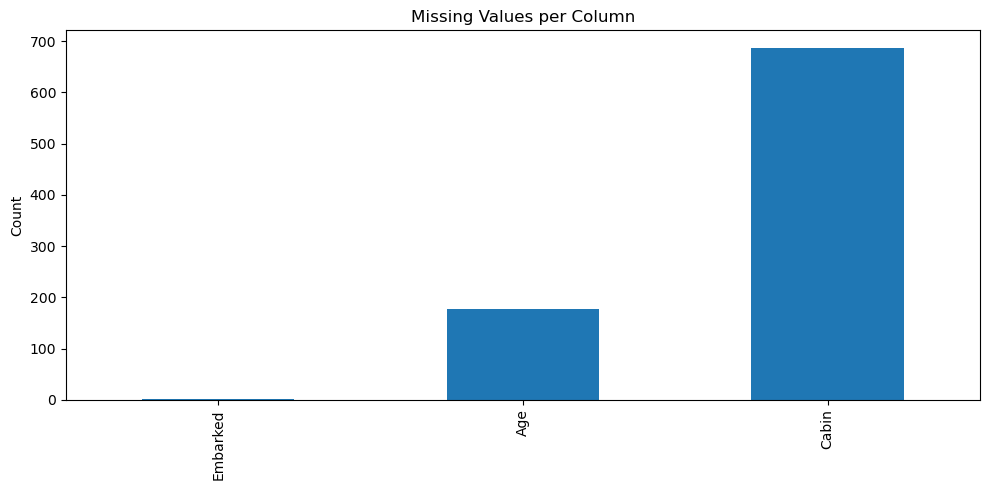

In [5]:
plot_missingness(df)



## 5. Zeroness
Check for high zero percentages in numeric columns to review sparse features.


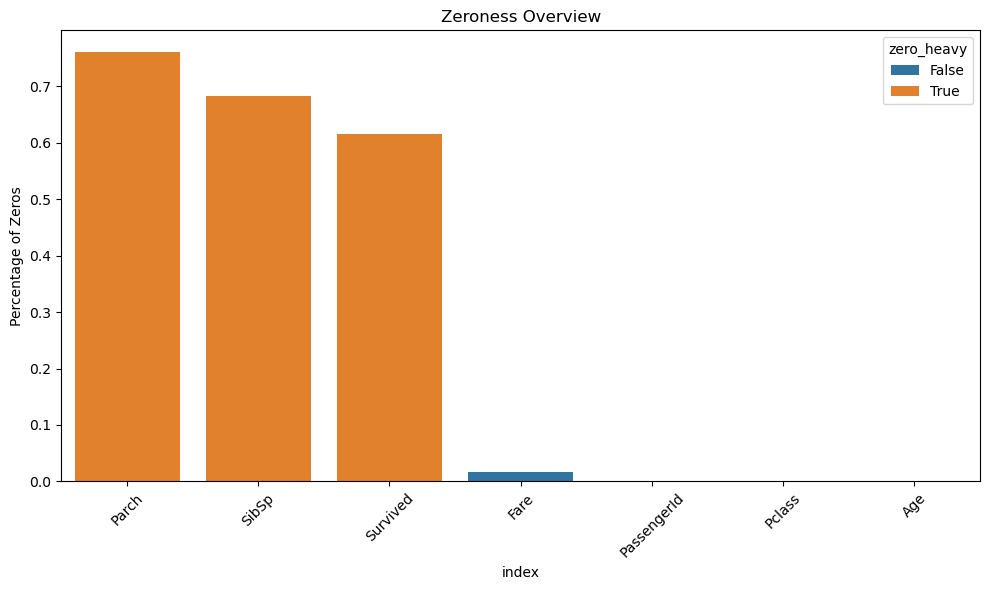

,zero_count,zero_pct,zero_heavy
Parch,678,0.760943,True
SibSp,608,0.682379,True
Survived,549,0.616162,True
Fare,15,0.016835,False
PassengerId,0,0.000000,False
Pclass,0,0.000000,False
Age,0,0.000000,False


In [6]:
from src.visualization.eda import plot_zeroness

zero_stats = plot_zeroness(df)
zero_stats


## 6. Numeric feature distributions
Review for skewness, outliers and multimodality. Heavily skewed features
may benefit from log transformation in `build_features.py`.

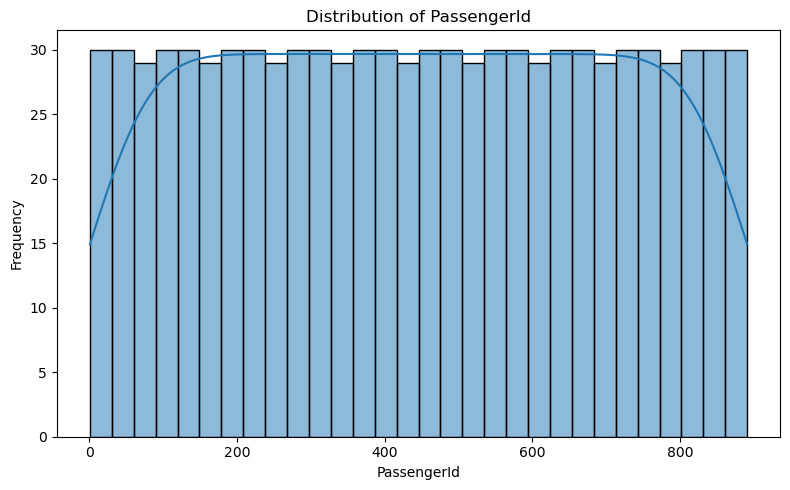

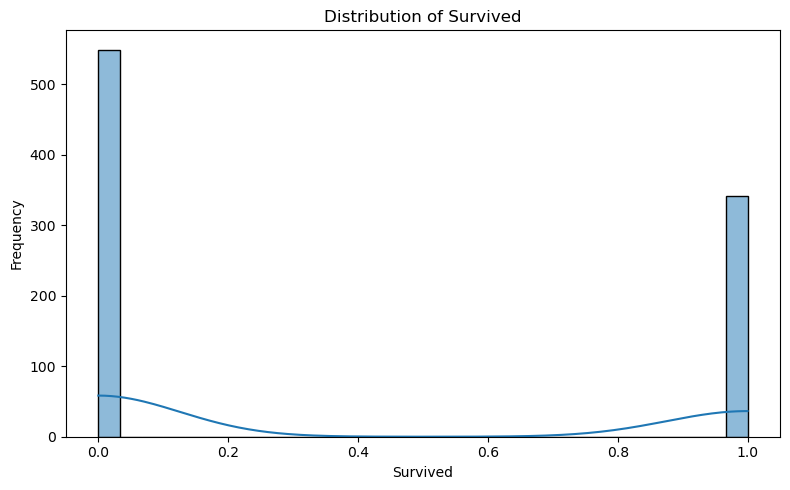

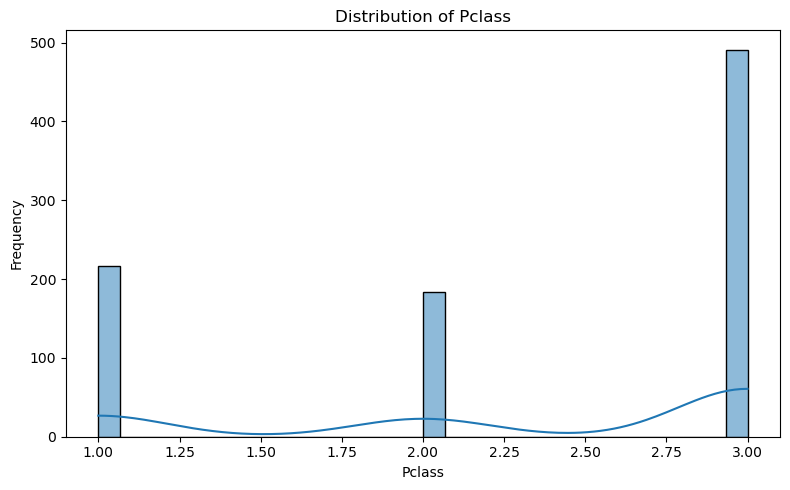

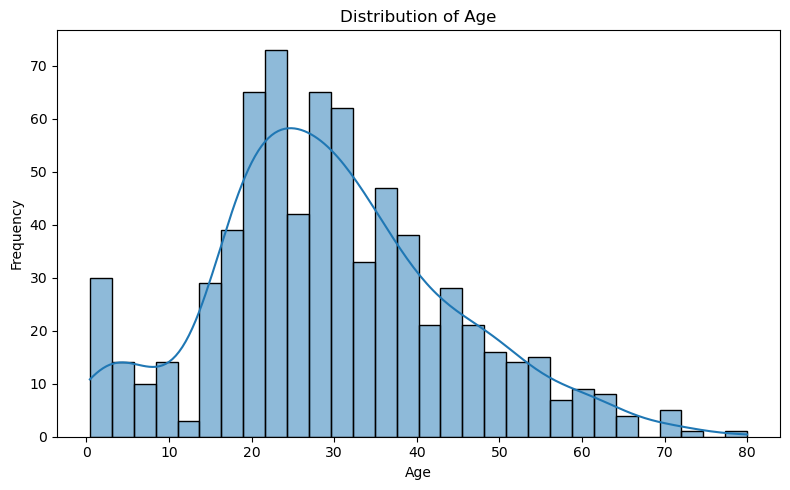

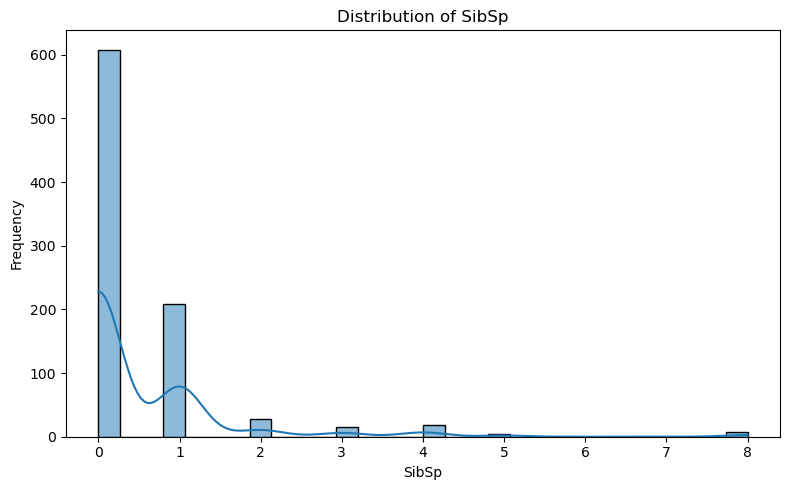

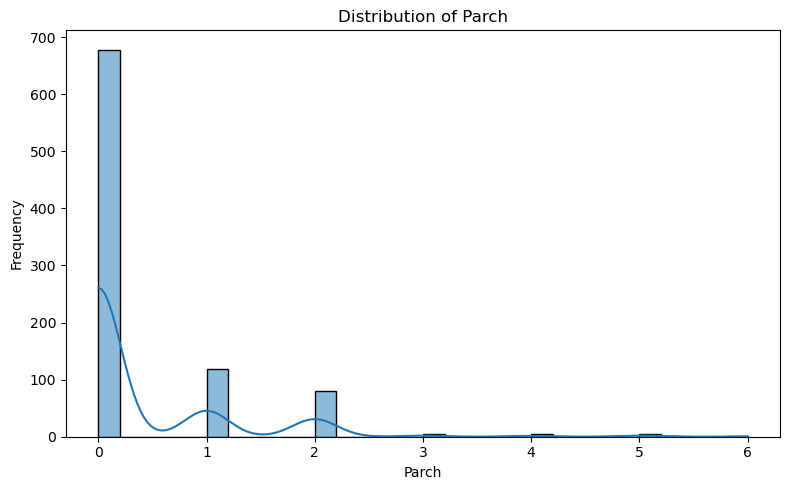

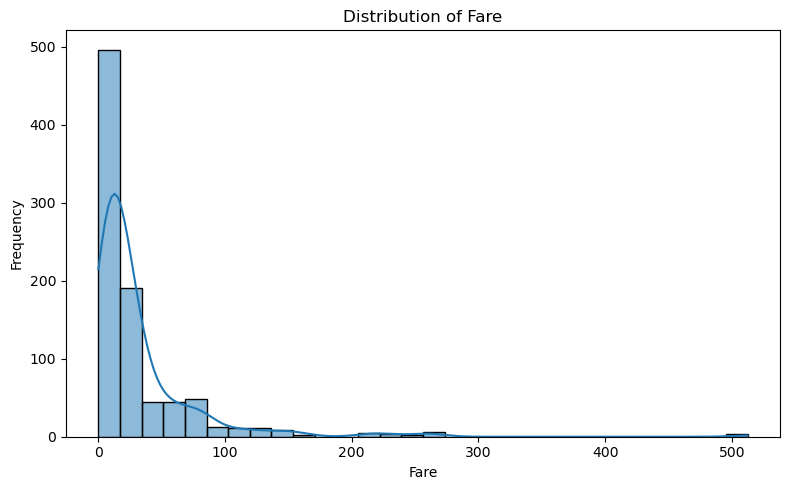

In [7]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    plot_numeric_distribution(df, col)


## 7. Categorical feature distributions
Review cardinality and class balance. High cardinality features will be
hash encoded by the pipeline — consider whether they carry useful signal.

[SKIPPED] 'Name' has 891 unique values (>20).
Top categories:


C:\Users\kigr\AppData\Local\Temp\ipykernel_33088\2340459315.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns


Name
Braund, Mr. Owen Harris                                    1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)        1
Heikkinen, Miss. Laina                                     1
Futrelle, Mrs. Jacques Heath (Lily May Peel)               1
Allen, Mr. William Henry                                   1
Moran, Mr. James                                           1
McCarthy, Mr. Timothy J                                    1
Palsson, Master. Gosta Leonard                             1
Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)          1
Nasser, Mrs. Nicholas (Adele Achem)                        1
Sandstrom, Miss. Marguerite Rut                            1
Bonnell, Miss. Elizabeth                                   1
Saundercock, Mr. William Henry                             1
Andersson, Mr. Anders Johan                                1
Vestrom, Miss. Hulda Amanda Adolfina                       1
Hewlett, Mrs. (Mary D Kingcome)                            1
Rice, Master. Eugen

Rare categories account for 97.76% of rows.


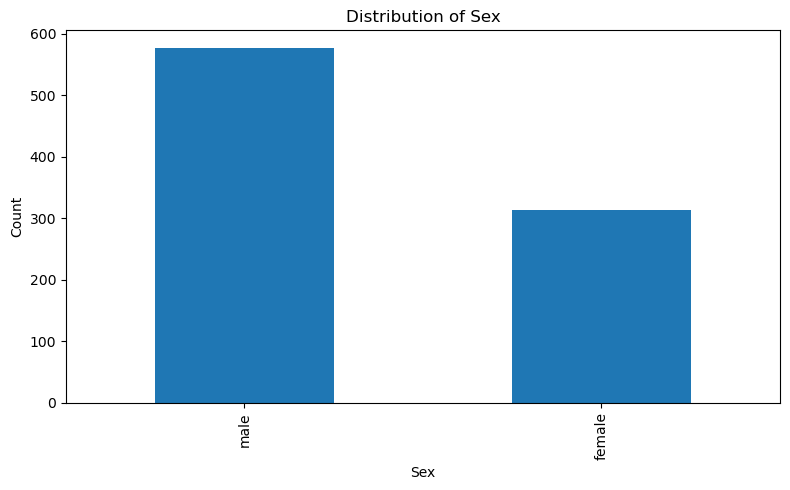

[SKIPPED] 'Ticket' has 681 unique values (>20).
Top categories:


Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
349909          4
347077          4
19950           4
W./C. 6608      4
4133            4
LINE            4
113781          4
17421           4
PC 17757        4
113760          4
2666            4
347742          3
Name: count, dtype: int64

Rare categories account for 89.23% of rows.
[SKIPPED] 'Cabin' has 147 unique values (>20).
Top categories:


Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
F2             3
D              3
C22 C26        3
C123           2
D33            2
C52            2
B28            2
C83            2
F G73          2
D26            2
B58 B60        2
C2             2
E33            2
F4             2
D36            2
Name: count, dtype: int64

Rare categories account for 75.00% of rows.


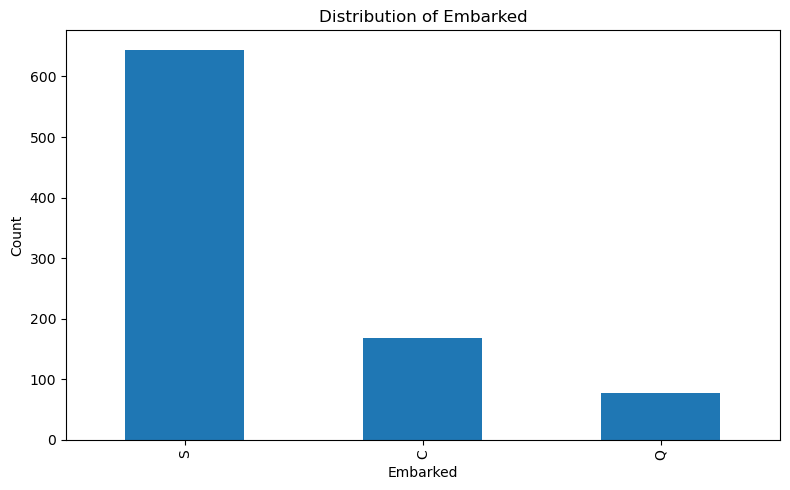

In [8]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    plot_categorical_distribution(df, col)


## 8. Target distribution
Confirm the problem type (classification vs regression) and check for
class imbalance. Severe imbalance may require stratified sampling or
class weighting — configure via `config.yaml`.

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

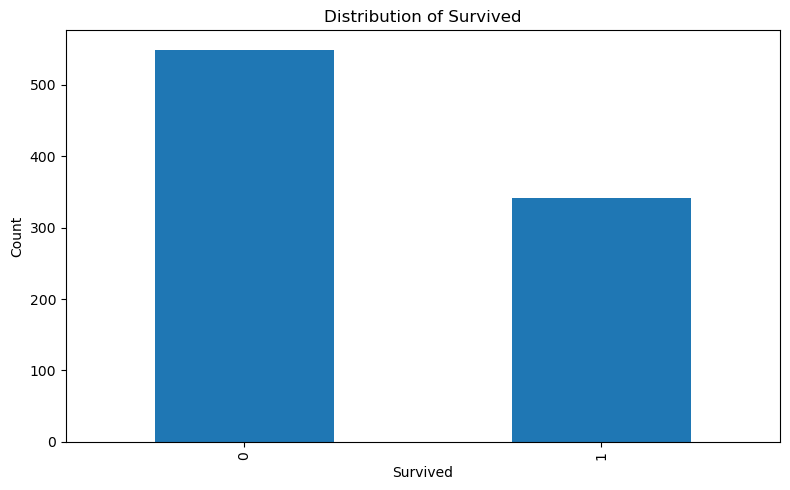

In [9]:
problem_type = detect_problem_type(df, TARGET)

if problem_type == "classification":
    display(df[TARGET].value_counts(normalize=True))
    plot_categorical_distribution(df, TARGET)
else:
    plot_numeric_target_distribution(df, TARGET)    




## 9. Feature-target relationships
Automatically plots the relationship between each feature and the target
using the appropriate chart type. Use these plots to identify strong
predictors for domain feature engineering in `build_features.py`.


🔍 Pairwise Feature–Target Analysis (classification)
Saving plots to: reports/figures/eda


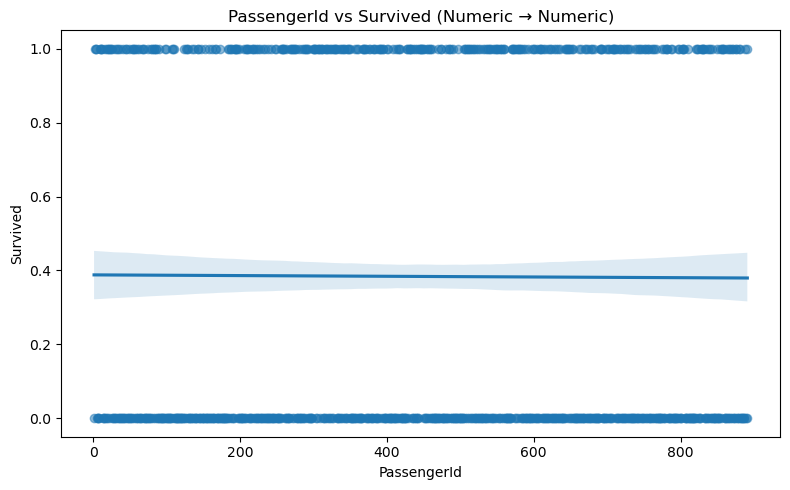

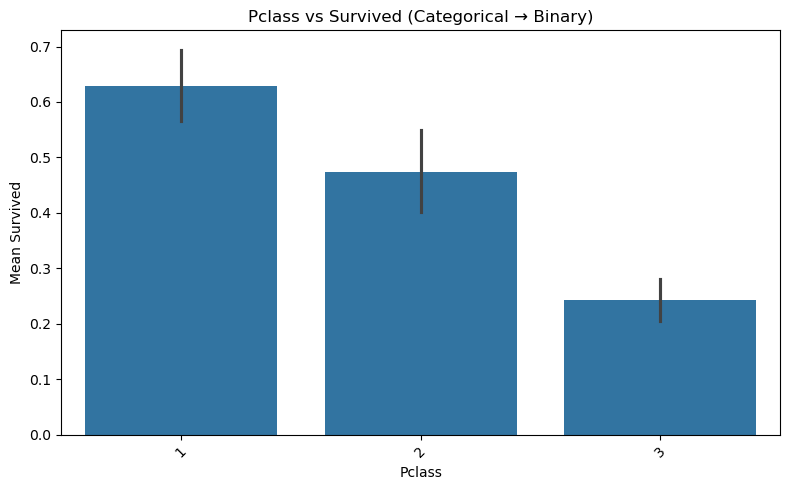

Skipping Name: unsupported type combination.
Skipping Sex: unsupported type combination.


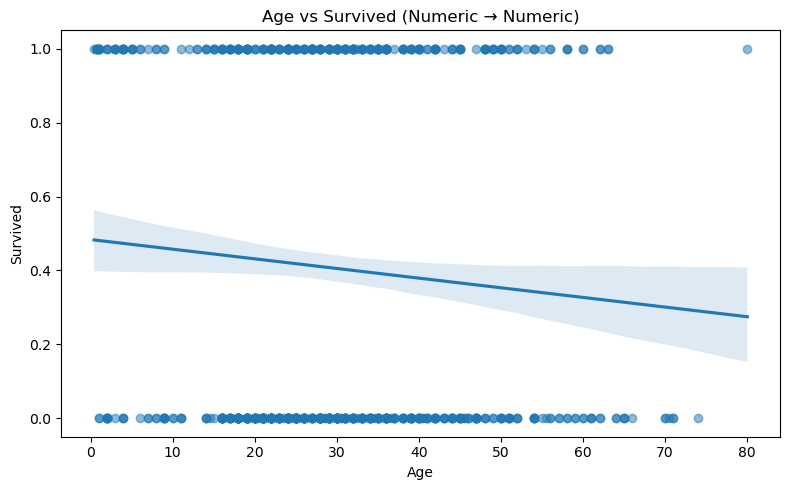

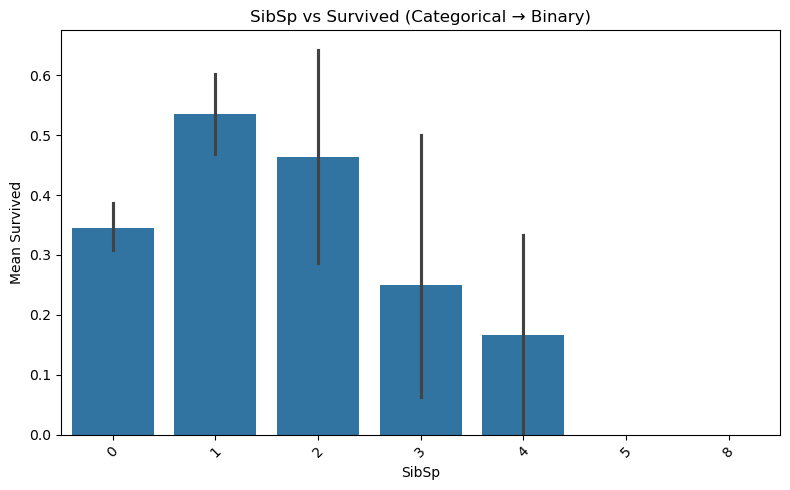

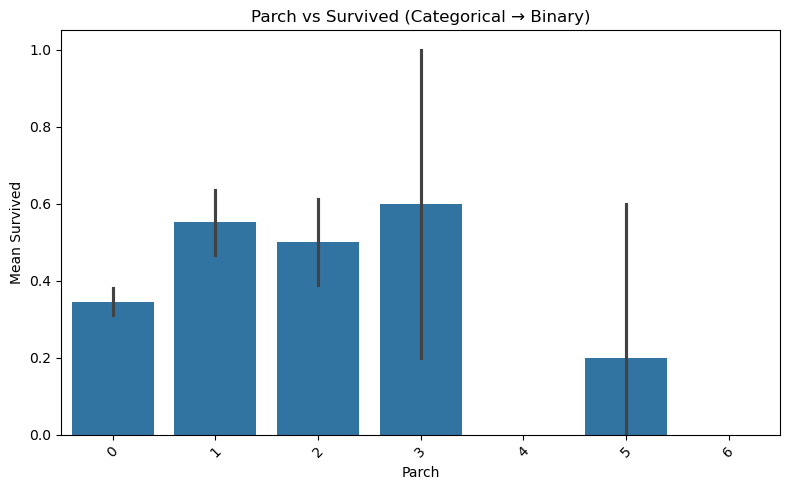

Skipping Ticket: unsupported type combination.


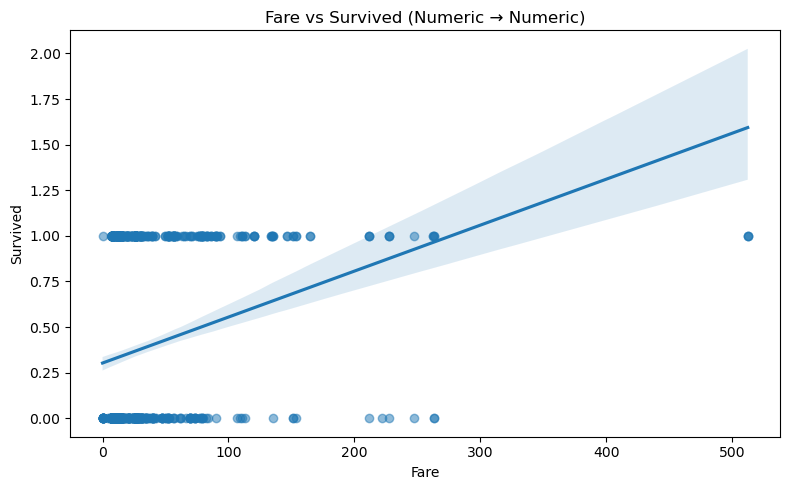

Skipping Cabin: unsupported type combination.
Skipping Embarked: unsupported type combination.


In [10]:
analyze_feature_target_relationships(df, TARGET)

## 10. Feature-feature interactions
Computes correlation, Cramér's V and mutual information between features.
Highly correlated feature pairs may be candidates for removal via
`correlation_threshold` in `config.yaml`.

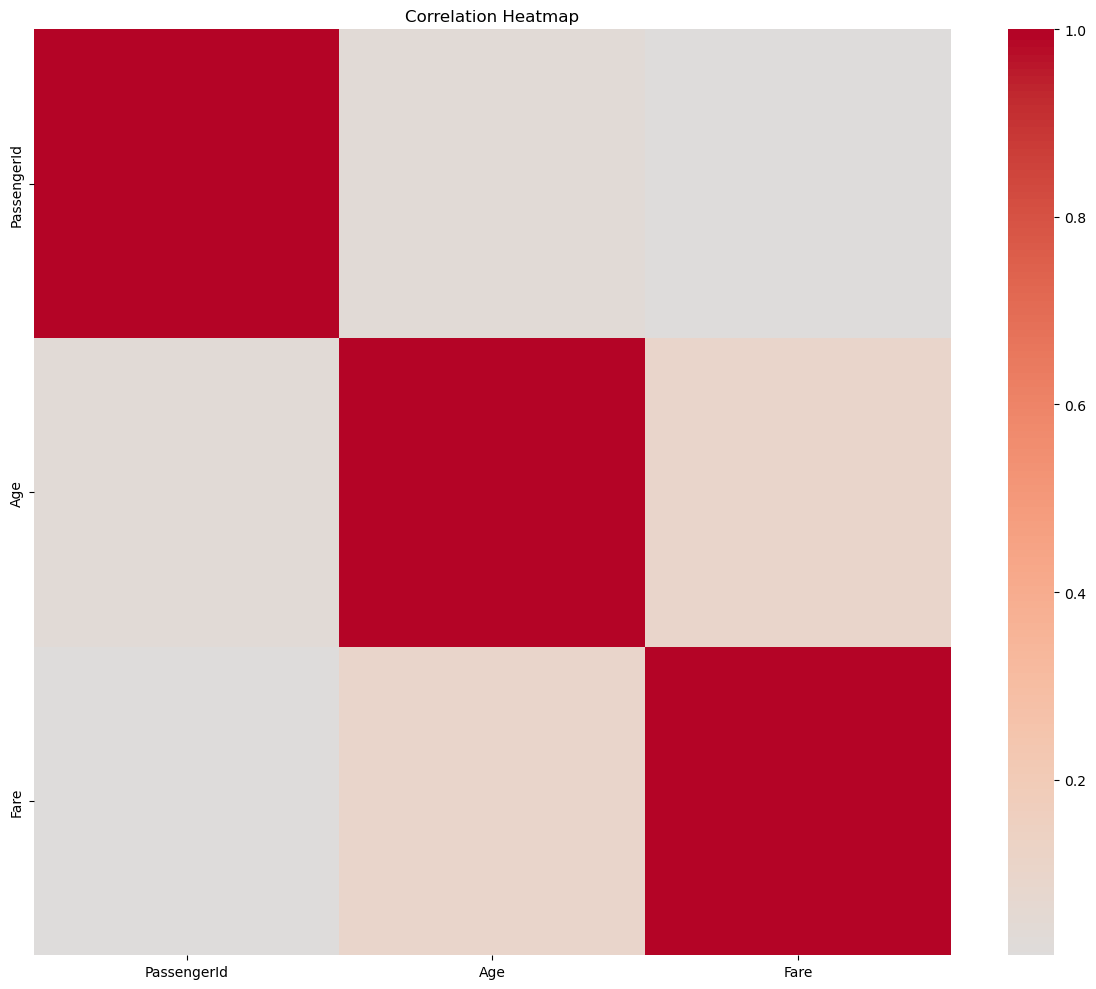

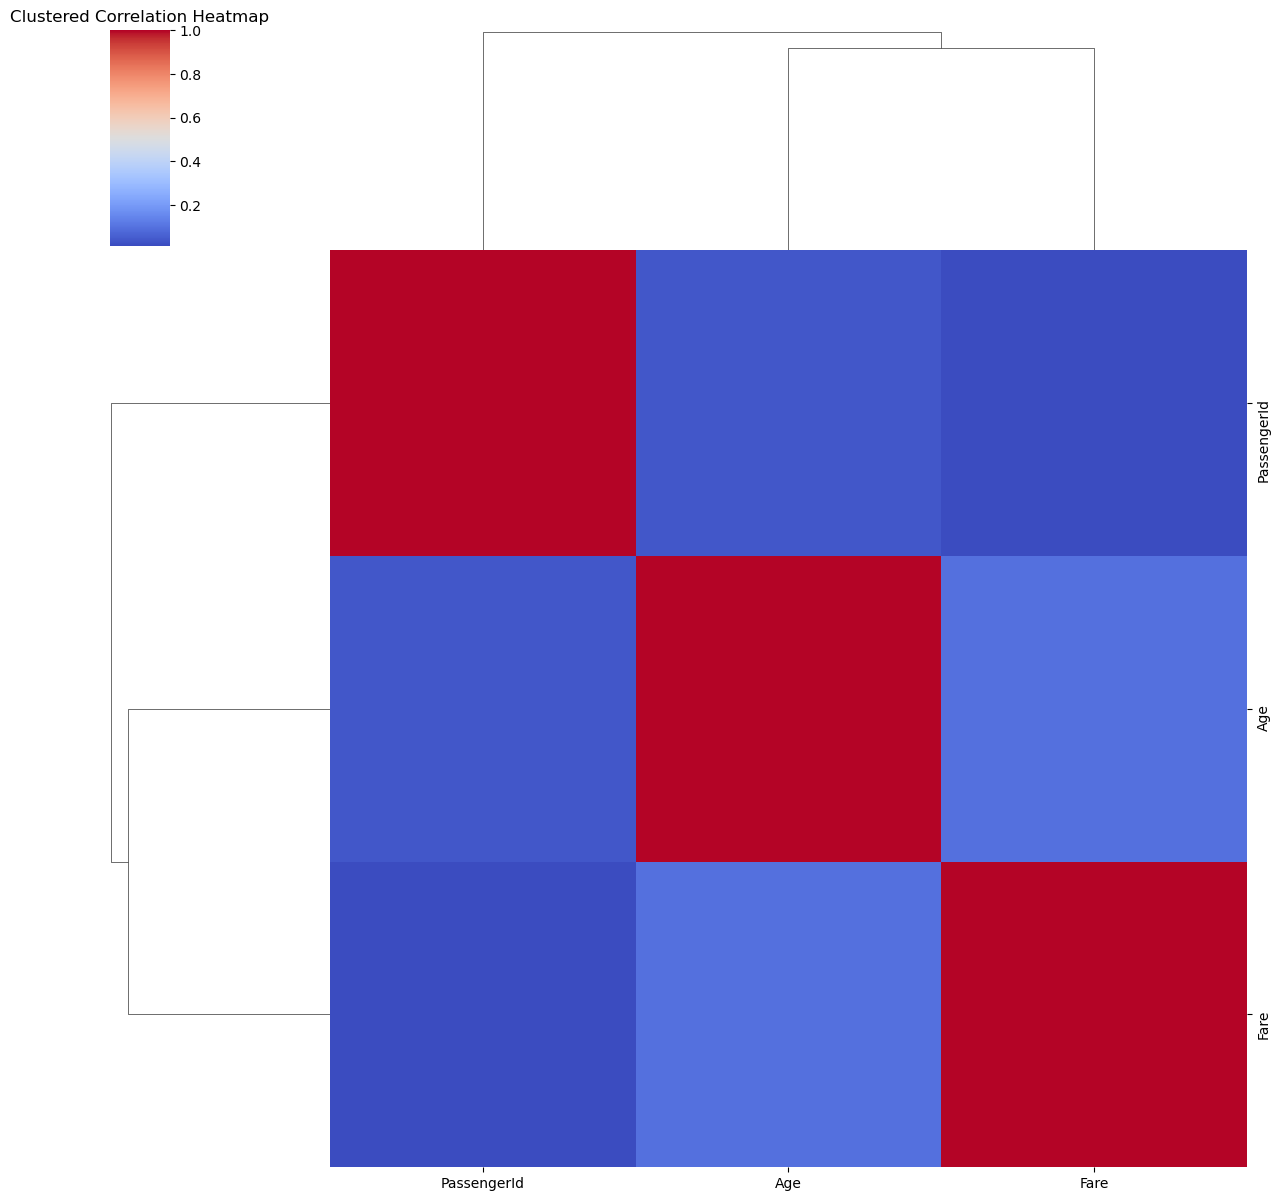

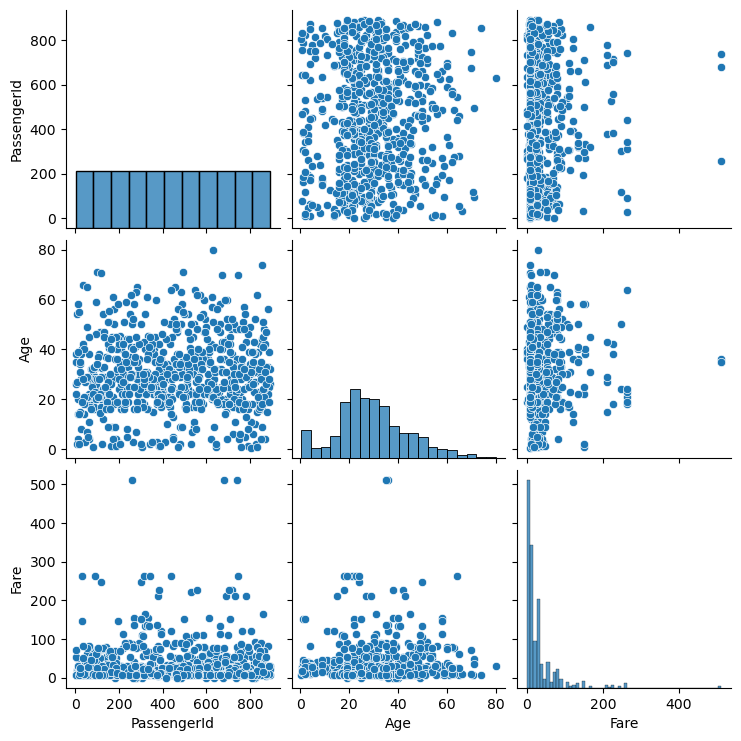

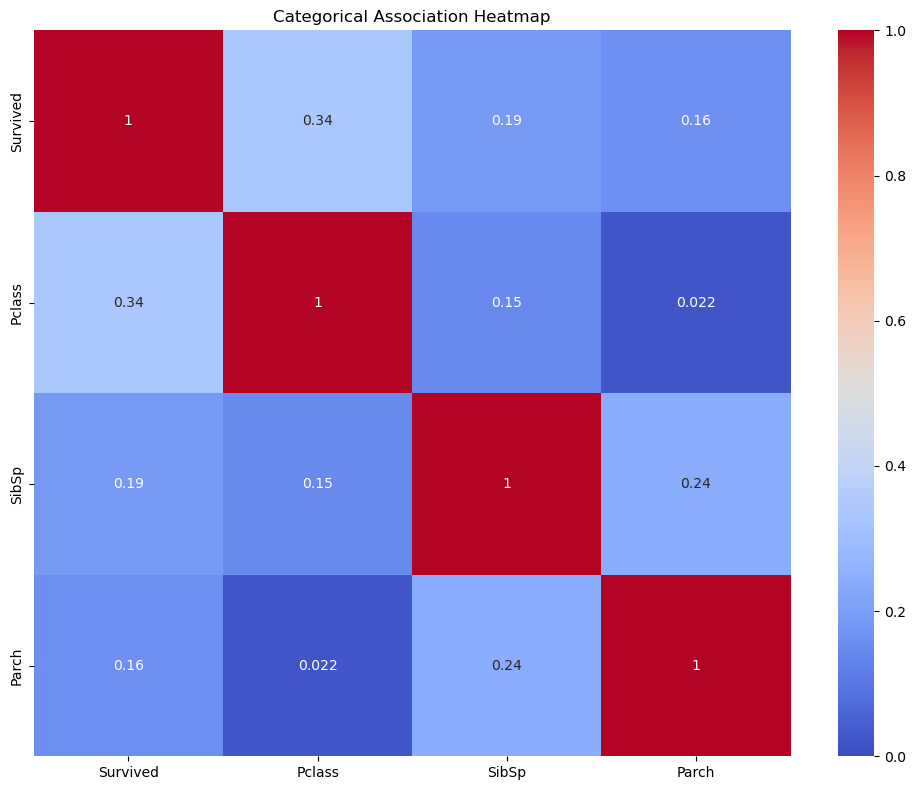

{'correlation_matrix':              PassengerId       Age      Fare
 PassengerId     1.000000  0.036847  0.012658
 Age             0.036847  1.000000  0.096067
 Fare            0.012658  0.096067  1.000000,
 'cramers_v':           Survived    Pclass     SibSp     Parch
 Survived  1.000000  0.336684  0.187428  0.156934
 Pclass    0.336684  1.000000  0.147816  0.021952
 SibSp     0.187428  0.147816  1.000000  0.239917
 Parch     0.156934  0.021952  0.239917  1.000000,
 'theils_u':           Survived    Pclass     SibSp     Parch
 Survived  1.000000  0.087260  0.034835  0.024576
 Pclass    0.058243  1.000000  0.035129  0.009454
 SibSp     0.025002  0.037774  1.000000  0.152378
 Parch     0.020925  0.012060  0.180768  1.000000,
 'mutual_information': {},
 'anova_f_scores': {'Survived': Fare           63.030764
  PassengerId     0.022285
  Age                  NaN
  dtype: float64,
  'Pclass': Fare           242.344157
  PassengerId      0.569832
  Age                   NaN
  dtype: float64

In [11]:
feature_feature_results = analyze_feature_feature_relationships(df)

feature_feature_results
